# iprPy stacking_fault_map_2D calculation

In [1]:
# Standard library imports
import datetime
from copy import deepcopy

# http://www.numpy.org/
import numpy as np

# https://ipython.org/
from IPython.display import display, Code, Markdown, Pretty

import matplotlib.pyplot as plt

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc

# https://github.com/usnistgov/iprPy
import iprPy

print('Notebook last executed on', datetime.date.today(), 'using iprPy version', iprPy.__version__)

Notebook last executed on 2026-06-26 using iprPy version 0.12.a


## 1. Load calculation and view description

### 1.1. Load the calculation

In [2]:
# Load the calculation being demoed
calculation = iprPy.load_calculation('stacking_fault_map_2D')

### 1.2. Display calculation description and theory

In [3]:
# Display main docs and theory
display(Markdown(calculation.maindoc))
display(Markdown(calculation.theorydoc))

# stacking_fault_map_2D calculation style

**Lucas M. Hale**, [lucas.hale@nist.gov](mailto:lucas.hale@nist.gov?Subject=ipr-demo), *Materials Science and Engineering Division, NIST*.

## Introduction

The stacking_fault_map_2D calculation style evaluates the full 2D generalized stacking fault map for an array of shifts along a specified crystallographic plane.  A regular grid of points is established and the generalized stacking fault energy is evaluated at each.

### Version notes

- 2018-07-09: Notebook added.
- 2019-07-30: Description updated and small changes due to iprPy version.
- v0.10.0: Version 0.10 update - potentials now loaded from database.
- 2020-09-22: Calculation updated to use atomman.defect.StackingFault class. Setup and parameter definition streamlined.
- v0.11.0: Notebook updated to reflect version 0.11.
- v0.12.0: Method updated to support the LAMMPS library interface.  
  
### Additional dependencies

### Disclaimers

- [NIST disclaimers](http://www.nist.gov/public_affairs/disclaimer.cfm)
- The system's dimension perpendicular to the fault plane should be large to minimize the interaction of the free surface and the stacking fault.


## Method and Theory

First, an initial system is generated.  This is accomplished using atomman.defect.StackingFault, which

1. Starts with a unit cell system.

2. Generates a transformed system by rotating the unit cell such that the new
   system's box vectors correspond to crystallographic directions, and filled
   in with atoms to remain a perfect bulk cell when the three boundaries are
   periodic.

3. All atoms are shifted by a fractional amount of the box vectors if needed.

4. A supercell system is constructed by combining multiple replicas of the
   transformed system.

5. The system is then cut by making one of the box boundaries non-periodic.  A limitation placed on the calculation is that the normal to the cut plane must correspond to one of the three Cartesian ($x$, $y$, or $z$) axes.  If true, then of the system's three box vectors ($\vec{a}$, $\vec{b}$, and $\vec{c}$), two will be parallel to the plane, and the third will not.  The non-parallel box vector is called the cutboxvector, and for LAMMPS compatible systems, the following conditions can be used to check the system's compatibility:

   - cutboxvector = 'c': all systems allowed.

   - cutboxvector = 'b': the system's yz tilt must be zero.

   - cutboxvector = 'a': the system's xy and xz tilts must be zero.

A LAMMPS simulation performs an energy/force minimization on the system where the atoms are confined to only relax along the Cartesian direction normal to the cut plane.

A mathematical fault plane parallel to the cut plane is defined in the middle of the system.  A generalized stacking fault system can then be created by shifting all atoms on one side of the fault plane by a vector, $\vec{s}$.  The shifted system is then relaxed using the same confined energy/force minimization used on the non-shifted system.  The generalized stacking fault energy, $\gamma$, can then be computed by comparing the total energy of the system, $E_{total}$, before and after $\vec{s}$ is applied

$$ \gamma(\vec{s}) = \frac{E_{total}(\vec{s}) - E_{total}(\vec{0})}{A},$$

where $A$ is the area of the fault plane, which can be computed using the two box vectors, $\vec{a_1}$ and $\vec{a_2}$, that are not the cutboxvector.

$$A = \left| \vec{a_1} \times \vec{a_2} \right|,$$

Additionally, the relaxation normal to the glide plane is characterized using the center of mass of the atoms above and below the cut plane.  Notably, the component of the center of mass normal to the glide/cut plane is calculated for the two halves of the the system, and the difference is computed

$$ \delta = \left<x\right>^{+} - \left<x\right>^{-}.$$

The relaxation normal is then taken as the change in the center of mass difference after the shift is applied.

$$ \Delta\delta = \delta(\vec{s}) - \delta(\vec{0}).$$

The stacking_fault_map_2D calculation evaluates both $\gamma$ and $\Delta\delta$ for a complete 2D grid of $\vec{s}$ values.  The grid is built by taking fractional steps along two vectors parallel to the shift plane.


## 2. Display the underlying code

This section displays the underlying code used when calculation.calc() is called in Section 4. It is provided here allowing any users to see and understand how the calculation works.

Feel free to modify and test the functions for yourself!  You can do this by
1. Copy the Python code displayed here into a "Code" cell and run it.
2. In Section 2.2, set "savefiles = True" and run the cell to save any supporting non-python files to the working directory.
3. In Section 4, call the primary calculation function directly rather than using calculation.calc().

### 2.1. Show code and supporting file names and content

In [4]:
# Display calculation code and supporting files
for filename, contents in calculation.files.items():
    display(Markdown(f'## Contents of file "{filename}"'))
    if filename[-3:] == '.py':
        display(Code(contents, language='python'))
    else:
        display(Pretty(contents))

## Contents of file "stacking_fault_map_2D.py"

# Python script created by Lucas Hale and Norman Luu.

# Standard library imports
from pathlib import Path
from typing import Optional, Union
import shutil

# http://www.numpy.org/
import numpy as np 

# https://github.com/usnistgov/atomman 
import atomman as am
import atomman.unitconvert as uc
from atomman.typing import lammpspotential, unitfloat, lammps, millerindices
from atomman.lammps import LAMMPS, LAMMPSobj

def stackingfaultmap(lammps_command: Union[str, LAMMPSobj],
                     ucell: am.System,
                     potential: lammpspotential,
                     hkl: millerindices,
                     mpi_command: Optional[str] = None,
                     sizemults: Union[list, tuple, None] = None,
                     minwidth: Optional[unitfloat] = None,
                     even: bool = False,
                     a1vect_uvw: Union[millerindices] = None,
                     a2vect_uvw: Union[millerindices] = None,
                     conventional_setting: str = 'p',
                     cutboxvector: str = 'c',
                     faultpos_rel: Optional[float] = None,
                     faultpos_cart: Optional[float] = None,
                     num_a1: int = 10,
                     num_a2: int = 10,
                     atomshift: Union[list, np.ndarray, None] = None,
                     shiftindex: Optional[int] = None,
                     etol: float = 0.0,
                     ftol: unitfloat = 0.0,
                     maxiter: int = 10000,
                     maxeval: int = 100000,
                     dmax: unitfloat = '0.01 angstrom',
                     usefiles: bool = False) -> dict:
    """
    Computes a generalized stacking fault map for shifts along a regular 2D
    grid.
    
    Parameters
    ----------
    lammps_command : str, LAMMPSEXE or LAMMPSLIB
        LAMMPS executable command, LAMMPS library name, or an atomman LAMMPS
        interface object.
    ucell : atomman.System
        The crystal unit cell to use as the basis of the stacking fault
        configurations.
    potential : aPotentialLAMMPS or PotentialLAMMPSKIM
        The LAMMPS implemented potential to use.
    hkl : array-like object or str
        The Miller(-Bravais) crystal fault plane relative to ucell.
    mpi_command : str, optional
        The MPI command for running LAMMPS in parallel.  If not given, LAMMPS
        will run serially.
    sizemults : list or tuple, optional
        The three System.supersize multipliers [a_mult, b_mult, c_mult] to use on the
        rotated cell to build the final system. Note that the cutboxvector sizemult
        must be an integer and not a tuple.  Default value is [1, 1, 1].
    minwidth : float or str, optional
        If given, the sizemult along the cutboxvector will be selected such that the
        width of the resulting final system in that direction will be at least this
        value. If both sizemults and minwidth are given, then the larger of the two
        in the cutboxvector direction will be used. 
    even : bool, optional
        A True value means that the sizemult for cutboxvector will be made an even
        number by adding 1 if it is odd.  Default value is False.
    a1vect_uvw : array-like object or str, optional
        The crystal vector to use for one of the two shifting vectors.  If
        not given, will be set to the shortest in-plane lattice vector.
    a2vect_uvw : array-like object or str, optional
        The crystal vector to use for one of the two shifting vectors.  If
        not given, will be set to the shortest in-plane lattice vector not
        parallel to a1vect_uvw.
    conventional_setting : str, optional
        Allows for rotations of a primitive unit cell to be determined from
        (hkl) indices specified relative to a conventional unit cell.  Allowed
        settings: 'p' for primitive (no conversion), 'f' for face-centered,
        'i' for body-centered, and 'a', 'b', or 'c' for side-centered.  Default
        b

### 2.2. Optional: Save supporting files

Set "savefiles = True" to save files locally.  

Note that the code above should be using atomman.tools.read_calc_file() to read the files, which will read any local files with matching names if they exist or read the packaged version if the local files do not exist. This means that if you save the files locally, you can modify them and see how it affects the calculation!

In [5]:
savefiles = False

if savefiles:
    for filename, contents in calculation.files.items():
        if filename[-3:] != '.py':
            with open(filename, 'w') as f:
                f.write(contents)

## 3. Specify input parameters

### 3.1. System-specific paths

- __lammps_command__ is the LAMMPS command to use (required).
- __mpi_command__ MPI command for running LAMMPS in parallel. A value of None will run simulations serially.

In [6]:
lammps_command = 'lmp_serial'
mpi_command = None
#mpi_command = 'mpiexec -localonly 4'

# Optional: check that LAMMPS works and show its version 
print(f'LAMMPS version = {am.lammps.checkversion(lammps_command)["version"]}')

LAMMPS version = 3 Mar 2020


### 3.2. Interatomic potential

- __potential_name__ gives the name of a potential_LAMMPS record to find and download from the iprPy library.  
- __potential__ is a potential_LAMMPS or potential_LAMMPS_KIM record object (required).

See documentation for the [potentials package](https://github.com/usnistgov/potentials/tree/master/doc) for more options on finding, loading and building potential objects (doc Notebook #s 0, 5.3, 5.4 and 7).

In [7]:
potential_name = '1999--Mishin-Y--Ni--LAMMPS--ipr1'

# Retrieve potential and parameter file(s) using atomman
potential = am.load_lammps_potential(id=potential_name, getfiles=True)

### 3.3. Initial unit cell system

- __ucell__ is an atomman.System representing a fundamental unit cell of the system (required).  Here, this is generated by loading the relaxed fcc crystal for the potential from the database.

See documentation for the [atomman package](https://github.com/lmhale99/atomman/tree/master/doc/tutorial) for more options on building and loading atomic configurations (doc Notebook #s 1.1, 1.2, 1.3, 1.4 and 1.4.*)

In [8]:
# Create ucell by loading prototype record
ucell = am.load('crystal', potential=potential, family='A1--Cu--fcc')

print(ucell)

Multiple matching record retrieved from remote
#  family               symbols  alat    Ecoh    method  standing
 1 A1--Cu--fcc          Ni        3.5200 -4.4500 dynamic good
 2 A1--Cu--fcc          Ni        7.3760  0.0119 dynamic good


Please select one: 1


avect =  [ 3.520,  0.000,  0.000]
bvect =  [ 0.000,  3.520,  0.000]
cvect =  [ 0.000,  0.000,  3.520]
origin = [ 0.000,  0.000,  0.000]
natoms = 4
natypes = 1
symbols = ('Ni',)
pbc = [ True  True  True]
per-atom properties = ['atype', 'pos']
     id |   atype |  pos[0] |  pos[1] |  pos[2]
      0 |       1 |   0.000 |   0.000 |   0.000
      1 |       1 |   0.000 |   1.760 |   1.760
      2 |       1 |   1.760 |   0.000 |   1.760
      3 |       1 |   1.760 |   1.760 |   0.000


### 3.4. Defect parameters

- __hkl__ gives the Miller (hkl) or Miller-Bravais (hkil) plane to create the free surface on.
- __cutboxvector__ specifies which of the three box vectors ('a', 'b', or 'c') is to be made non-periodic to create the free surface. 
- __shiftindex__ can be used for complex crystals to specify different termination planes.
- __a1vect_uvw, a2vect_uvw__ specify two non-parallel Miller crystal vectors within the fault plane corresponding to full planar shifts from one perfect crystal configuration to another.  
- __num_a1, num_a2__ specify how many measurements to make along a1vect_uvw, a2vect_uvw respectively.

In [9]:
hkl = [1, 1, 1]
cutboxvector = 'c'
shiftindex = 0
a1vect_uvw = [ 0.0,-0.5, 0.5]
a2vect_uvw = [ 0.5,-0.5, 0.0]
num_a1 = 30
num_a2 = 30

### 3.5. System modifications

- __sizemults__  list of three integers specifying how many times the ucell vectors of $a$, $b$ and $c$ are replicated in creating system.
- __minwidth__ specifies a minimum width that the system should be along the cutboxvector direction. The given sizemult in that direction will be increased if needed to ensure that the system is at least this wide. 

In [10]:
sizemults = [5, 5, 10]
minwidth = uc.set_in_units(0.0, 'angstrom')

### 3.5. Calculation-specific parameters

- __energytolerance__ is the energy tolerance to use during the minimizations. This is unitless.
- __forcetolerance__ is the force tolerance to use during the minimizations. This is in energy/length units.
- __maxiterations__ is the maximum number of minimization iterations to use.
- __maxevaluations__ is the maximum number of minimization evaluations to use.
- __maxatommotion__ is the largest distance that an atom is allowed to move during a minimization iteration. This is in length units.

In [11]:
energytolerance = 1e-8
forcetolerance = uc.set_in_units(0.0, 'eV/angstrom')
maxiterations = 10000
maxevaluations = 100000
maxatommotion = uc.set_in_units(0.01, 'angstrom')

## 4. Run calculation and view results

### 4.1. Run calculation

All primary calculation method functions take a series of inputs and return a dictionary of outputs.

In [12]:
# What is calculation.calc an alias of?
calculation.calc.__module__

'iprPy.calculation.stacking_fault_map_2D.stacking_fault_map_2D'

In [13]:
results_dict = calculation.calc(lammps_command, ucell, potential, hkl,
                                mpi_command = mpi_command,
                                sizemults = sizemults,
                                minwidth = minwidth,
                                a1vect_uvw = a1vect_uvw,
                                a2vect_uvw = a2vect_uvw,
                                cutboxvector = cutboxvector,
                                shiftindex = shiftindex,
                                num_a1 = num_a1,
                                num_a2 = num_a2, 
                                etol = energytolerance,
                                ftol = forcetolerance,
                                maxiter = maxiterations,
                                maxeval = maxevaluations,
                                dmax = maxatommotion)
print(results_dict.keys())

dict_keys(['A_fault', 'gamma'])


### 4.2. Report results

Values returned in the results_dict:

- **'A_fault'** (*float*) - The area of the fault surface.
- **'gamma'** (*atomman.defect.GammaSurface*) - A gamma surface
  plotting object.

In [14]:
length_unit = 'nm'
area_unit = 'nm^2'
energy_unit = 'eV'
energyperarea_unit = 'mJ/m^2'

In [15]:
print('A_fault =', uc.get_in_units(results_dict['A_fault'], area_unit), area_unit)

A_fault = 5.365198866947918 nm^2


In [16]:
gamma = results_dict['gamma']
print(gamma.a1vect)
print(gamma.a2vect)

[ 0.  -0.5  0.5]
[ 0.5 -0.5  0. ]


In [17]:
# Save gamma as data model
with open('gamma.json', 'w') as f:
    gamma.model().json(fp=f, indent=4)

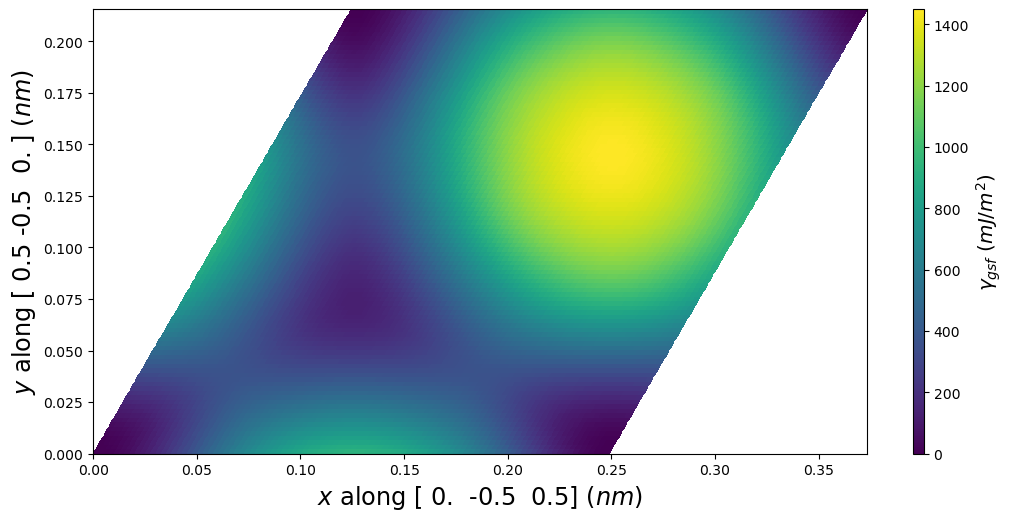

In [18]:
# Plot with calculation a1vect, a2vect
gamma.E_gsf_surface_plot(length_unit=length_unit,
                         energyperarea_unit=energyperarea_unit)
plt.show()

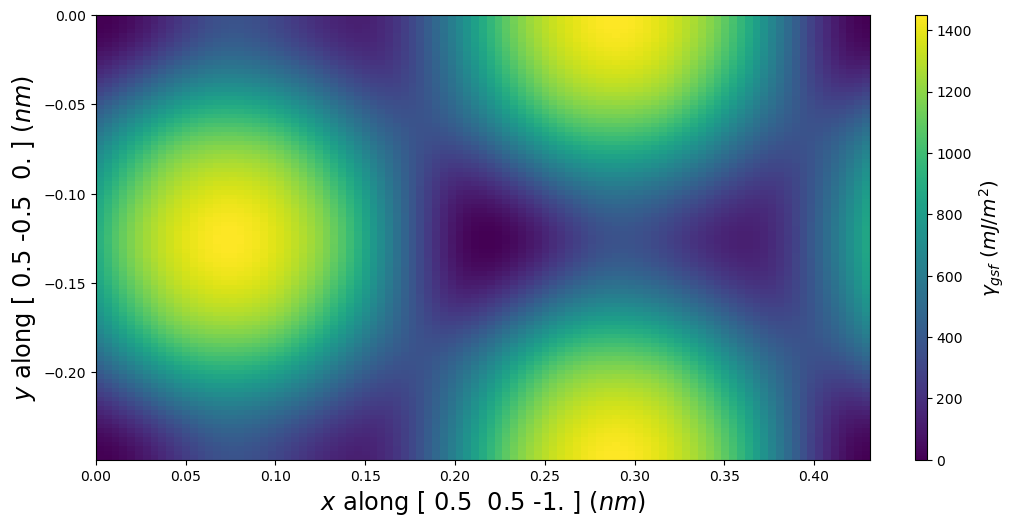

In [19]:
# Plot with standard A1--fcc--111sf a1vect, a2vect
gamma.E_gsf_surface_plot(a1vect=[0.5, 0.5, -1],
                         a2vect=gamma.a2vect,
                         length_unit=length_unit,
                         energyperarea_unit=energyperarea_unit)
plt.show()

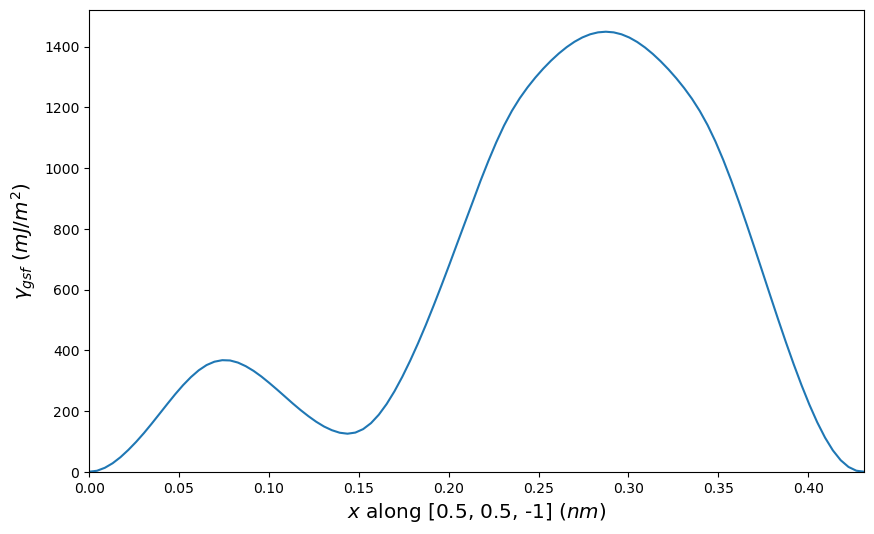

In [20]:
# Standard 1D [11-2](111) fcc path
gamma.E_gsf_line_plot(vect=[0.5, 0.5, -1], length_unit=length_unit,
                      energyperarea_unit=energyperarea_unit)
plt.show()

### 4.3. Optional: Clean calculation files

The calculation may generate output files when it runs.  Calling calculation.clean_files() will delete any generated files to keep the workspace clean.

In [21]:
calculation.clean_files()